### Some very simple goals

**Plot**
- Depth vs. WSAF
- ORT vs. WSAF
  - Color by genotype call
 
**Tabulate or show**
- Number of heterozygous calls (or prevalence of A724E) with changing WSAF threshodl

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [2]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
mpl.rcParams['font.family'] = 'Arial',
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [3]:
DIR_SEQDATA = "../seqdata/all/summaries/HRP23_MIS2024"
DIR_FIGS = "../figures/response"
os.makedirs(DIR_FIGS, exist_ok=True)
save_results = True

In [4]:
W = 3.4

## Load data

In [5]:
df_variants = (
    pd.read_csv(
        f"{DIR_SEQDATA}/summary.variants.analysis_set.csv",
        dtype=dict(sample_id=str)
    ).query("aa_change == 'A724E'")
)

Used the following command to extract other statistics about the calls at A724E:

```
bcftools query -r 'Pf3D7_13_v3:1724827' -f '[%SAMPLE\t%CHROM\t%POS\t%REF\t%ALT\t%GT\t%DP\t%VAF\t%ORT\t%LQR\n]' summary.variants.vcf.gz > summary.extract_A724E_statistics.tsv
```

In [6]:
df_stats = (pd.read_csv(f"{DIR_SEQDATA}/summary.extract_A724E_statistics.tsv",
                        sep="\t",
                        names=["sample_combined", "chom", "pos", "ref", "alt", "gt", "dp", "wsaf", "ort", "lqr"])
            .assign(
                expt_name=lambda df: [s.split("___")[0] for s in df["sample_combined"]],
                barcode=lambda df: [s.split("___")[1] for s in df["sample_combined"]],
            )
            .drop(['sample_combined'], axis=1)
           )[['expt_name', 'barcode', 'ort', 'lqr']]

## Merge

In [7]:
df_merged = pd.merge(
    left=df_variants,
    right=df_stats,
    on=['expt_name', 'barcode'],
    how='left',
    validate='1:1'
)

In [8]:
float_columns = ['ort', 'lqr']
for c in float_columns:
    df_merged[c] = df_merged[c].astype(float)

In [9]:
# Annotations
df_merged['mutant_reads'] = (df_merged['dp'] * df_merged['wsaf']).round(0)

## Plotting

In [10]:
LW = 0.3
S = 20
color_genotypes = dict(zip([1, 2], sns.color_palette('Paired', 2)))

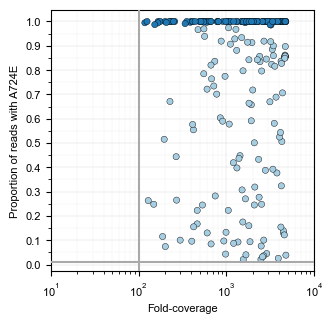

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))


ax.scatter(
    x="dp",
    y="wsaf",
    c=df_merged['gt_int'].map(color_genotypes),
    ec='black', 
    lw=LW,
    s=S,
    data=df_merged
)

ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.set_xscale("log")
ax.set_xlim(10, 10_000)

ax.set_axisbelow(True)
ax.axvline(100, color='darkgrey', lw=1.5, zorder=10)
ax.axhline(0.01, color='darkgrey', lw=1.5, zorder=10)
ax.grid(ls='solid', alpha=0.5, lw=LW)
ax.grid(ls='dotted', which='minor', alpha=0.5, lw=LW)

ax.set_xlabel("Fold-coverage")
ax.set_ylabel("Proportion of reads with A724E")

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.seqc.wsaf_depth.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.seqc.wsaf_depth.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

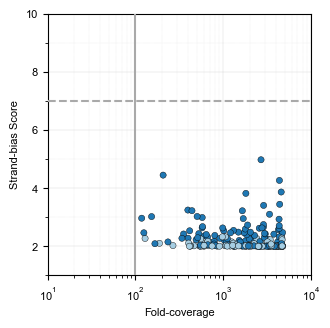

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))


ax.scatter(
    x="dp",
    y="ort",
    c=df_merged['gt_int'].map(color_genotypes),
    ec='black', 
    lw=LW,
    s=S,
    data=df_merged
)


ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))

ax.set_xscale("log")
ax.set_xlim(10, 10_000)
ax.set_ylim(1, 10)

ax.set_axisbelow(True)
ax.axvline(100, color='darkgrey', lw=1.5, zorder=10)
ax.axhline(7, color='darkgrey', ls='dashed', lw=1.5, zorder=10)
ax.grid(ls='solid', alpha=0.5, lw=LW)
ax.grid(ls='dotted', which='minor', alpha=0.5, lw=LW)

ax.set_xlabel("Fold-coverage")
ax.set_ylabel("Strand-bias Score")

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.seqc.ort_depth.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.seqc.ort_depth.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

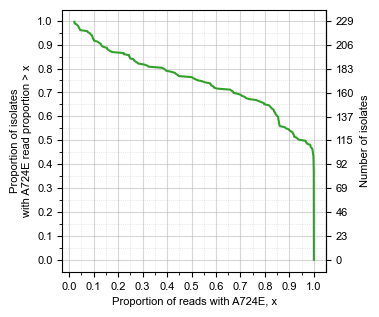

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

values = sorted(df_merged['wsaf'])
N = len(values)

ax.plot(values,
        np.arange(N)[::-1]/N,
        color=sns.color_palette("Paired", 4)[-1])

for _ax in [ax.yaxis, ax.xaxis]:
    _ax.set_major_locator(plt.MultipleLocator(0.1))
    _ax.set_minor_locator(plt.MultipleLocator(0.05))

ax.set_axisbelow(True)
ax.grid(ls='solid', which='major', alpha=0.5)
ax.grid(ls='dotted', which='minor', alpha=0.5, lw=0.5)

ax.set_xlabel("Proportion of reads with A724E, x")
ax.set_ylabel("Proportion of isolates\nwith A724E read proportion > x")

axm = ax.secondary_yaxis("right",
                         functions=(lambda y: y * N, lambda y: y/N))
axm.set_yticks([round(y, 0) for y in ax.get_yticks() * N])
axm.set_ylabel("Number of isolates")

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.seqc.survival_wsaf.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.seqc.survival_wsaf.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

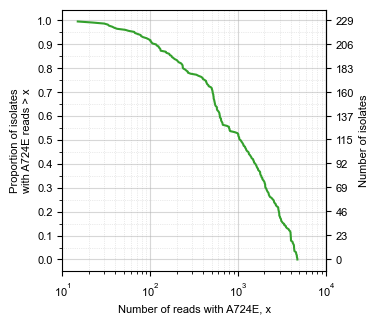

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

values = sorted(df_merged['mutant_reads'])
N = len(values)

ax.plot(values,
        np.arange(N)[::-1]/N,
        color=sns.color_palette("Paired", 4)[-1])

ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.set_xlim(10, 10_000)

ax.set_xscale("log")

ax.set_axisbelow(True)
ax.grid(ls='solid', which='major', alpha=0.5)
ax.grid(ls='dotted', which='minor', alpha=0.5, lw=0.5)
ax.set_xlabel("Number of reads with A724E, x")
ax.set_ylabel("Proportion of isolates\nwith A724E reads > x")

axm = ax.secondary_yaxis("right",
                         functions=(lambda y: y * N, lambda y: y/N))
axm.set_yticks([round(y, 0) for y in ax.get_yticks() * N])
axm.set_ylabel("Number of isolates")

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.seqc.survival_nreads.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.seqc.survival_nreads.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

## Summary statistics

In [15]:
df_summary = (
    df_merged[["dp", "wsaf", "mutant_reads", "ort"]]
    .describe()
    .drop(['count', 'std'], axis=0)
    .rename({"dp": "Total depth", "wsaf": "WSAF", "mutant_reads": "A724E depth", "ort": "Strand-bias Score"}, axis=1)
    .transpose()
)
df_summary.columns = df_summary.columns.str.title()
df_summary = df_summary.round(2)
df_summary

,Mean,Min,25%,50%,75%,Max
Total depth,2034.65,118.00,668.00,1742.00,3195.00,4761.00
WSAF,0.75,0.02,0.54,0.97,1.00,1.00
A724E depth,1549.47,15.00,434.00,1079.00,2533.00,4746.00
Strand-bias Score,2.50,2.00,2.01,2.08,2.38,19.58


In [16]:
if save_results:
    df_summary.to_csv(f"{DIR_FIGS}/table.seqc_stats.csv")
    df_summary.to_excel(f"{DIR_FIGS}/table.seqc_stats.xlsx")

In [17]:
df_merged['mutant_reads'].quantile([0.05, 0.1, 0.25, 0.5, 0.75])

0.05      69.0
0.10     118.6
0.25     434.0
0.50    1079.0
0.75    2533.0
Name: mutant_reads, dtype: float64

In [18]:
df_merged.query("gt_int == 1")['mutant_reads'].quantile([0.05, 0.1, 0.25, 0.5, 0.75])

0.05      38.7
0.10      70.5
0.25     185.5
0.50     622.0
0.75    1979.5
Name: mutant_reads, dtype: float64